# A minimal deck

Everything `portmanteau.slides.notebook_deck` understands, in four slides. Build it with:

```python
from portmanteau.slides.notebook_deck import build_deck
build_deck("minimal_deck.ipynb", out="minimal_deck.pptx")
```

No template is passed, so python-pptx's default is used; pass `template=` for your own.

**This cell is the deck title.** Only the `# ` line becomes the opening section slide - the rest of
the cell is for whoever edits the notebook. Everything before the first `##` is preamble and is
ignored, which is where imports go.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from portmanteau.slides.notebook_deck import init_slide_nb

# Always call this in the first code cell. A deck is built from what the notebook *displayed*, so
# anything abbreviated for the notebook's own readability is abbreviated on the slide too - pandas
# truncates a table cell past 50 characters by default. It also warns if matplotlib is on a backend
# that will not display figures, which the build would otherwise only discover much later.
init_slide_nb()

## Bullets, and what the markdown does

### prep

In [2]:
# `prep` is for setting things up. Its output is never rendered, so print and inspect freely.
seasons = pd.DataFrame({"quarter": ["Q1", "Q2", "Q3"], "sales": [1200, 1750, 1430]})
seasons.describe()

,sales
count,3.000000
mean,1460.000000
std,276.224546
min,1200.000000
25%,1315.000000
50%,1430.000000
75%,1590.000000
max,1750.000000


### text

- A line starting with a dash is a bullet
- Two spaces of indent nests it
  - like this
- **Bold**, *italic* and `code` all work

A line that is not a list item becomes a lead-in with no
bullet glyph, which is how you label a group

- A blank line ends whatever is open, so this is a new
  bullet rather than more of the lead-in

### notes

This becomes the speaker notes for the slide, and is a good place for the detail that would not fit
on it. Markdown here is passed through as plain text rather than parsed.

This slide has no `### images` section, which is fine - a slide needs text or images, not both.

## One figure sits beside the bullets

### prep

In [3]:
quarterly = seasons.set_index("quarter").sales
quarterly

quarter
Q1    1200
Q2    1750
Q3    1430
Name: sales, dtype: int64

### text

- Bullets take the left 46% of the slide
- A single figure is centred vertically on the right
- The fraction is a `DeckStyle` knob if you want a
  different split

### images

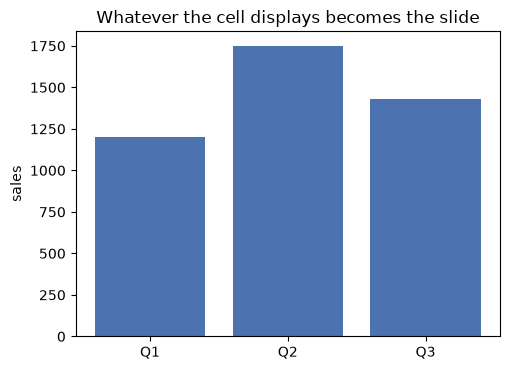

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.8))
ax.bar(quarterly.index, quarterly.values, color="#4C72B0")
ax.set_ylabel("sales")
ax.set_title("Whatever the cell displays becomes the slide")
fig.tight_layout()

### notes

An `### images` cell must actually display something. If it produces no output the build fails,
because a silently empty slide is worse than a broken build - move set-up into `### prep` instead.

## A table goes underneath instead

### prep

In [5]:
# format numbers as strings here: the builder keeps exactly what the cell displayed, so thousands
# separators and rounding survive onto the slide
table = seasons.assign(sales=lambda d: d.sales.map("{:,}".format)).set_index("quarter")
table

,sales
quarter,
Q1,"1,200"
Q2,"1,750"
Q3,"1,430"


### text

- A table is wide and a column of bullets is not, so the
  bullets go on **top** and the table full width beneath
- It becomes a real pptx table, not a picture of one
- The build fails if it would run off the bottom

### images

In [6]:
table

,sales
quarter,
Q1,"1,200"
Q2,"1,750"
Q3,"1,430"


### notes

A DataFrame is picked up from the cell's HTML output, so its index and column names come through as
written. The builder keeps the notebook's own formatting - `1,200` stays `1,200` rather than being
parsed back to an integer.

## Two figures stack

### prep

In [7]:
rolling = quarterly.cumsum()
rolling

quarter
Q1    1200
Q2    2950
Q3    4380
Name: sales, dtype: int64

### text

- Two figures stack vertically in the right-hand column
- **Three or more fails the build** - split the slide
- A table and a figure on one slide fails too

### images

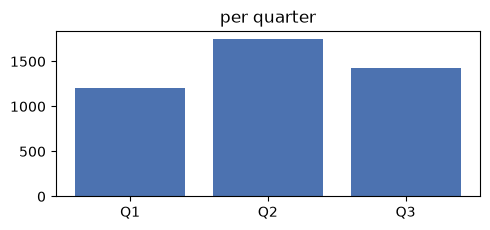

In [8]:
fig, ax = plt.subplots(figsize=(5.0, 2.4))
ax.bar(quarterly.index, quarterly.values, color="#4C72B0")
ax.set_title("per quarter")
fig.tight_layout()

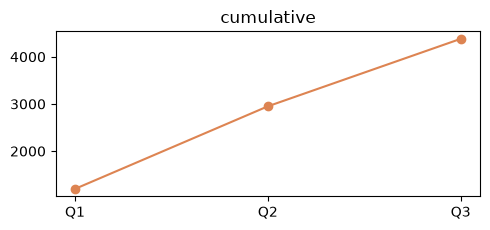

In [9]:
fig, ax = plt.subplots(figsize=(5.0, 2.4))
ax.plot(rolling.index, rolling.values, marker="o", color="#DD8452")
ax.set_title("cumulative")
fig.tight_layout()

### notes

Each displayed figure becomes one picture, in the order the cells ran. They can come from one cell
or from several - only the count matters.